In [1]:
from functools import reduce
import re
import itertools

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from src.categories import subcat_to_cat

import pickle

In [2]:
def load_preds(steps: list[int], base_path: str, n_shots_ls: list[int]):
    preds = []

    for step, n_shots in itertools.product(steps, n_shots_ls):
        preds_path = base_path.format(n_shots, step)

        with open(preds_path, 'rb') as f:
            preds_df: pd.DataFrame = pickle.load(file=f)
            preds_df.loc[:, 'step'] = step
            preds_df.loc[:, 'num shots'] = n_shots

            preds.append(preds_df)

            print(f"{step:5}: {preds_df.shape=}")
        
    preds = pd.concat(preds)
    return preds

In [3]:
LoRA_steps = [2000, 4000, 6000, 8000, 10_000, 12_000, 14_000]

LoRA_preds = load_preds(
    steps=LoRA_steps,
    base_path=r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\forgetting\LoRA-cfg18-code-ift\preds_{0}sh_st-{1}.bin',
    n_shots_ls=[0, 5],
)

LoRA_preds.head()

 2000: preds_df.shape=(14042, 9)
 2000: preds_df.shape=(14042, 9)
 4000: preds_df.shape=(14042, 9)
 4000: preds_df.shape=(14042, 9)
 6000: preds_df.shape=(14042, 9)
 6000: preds_df.shape=(14042, 9)
 8000: preds_df.shape=(14042, 9)
 8000: preds_df.shape=(14042, 9)
10000: preds_df.shape=(14042, 9)
10000: preds_df.shape=(14042, 9)
12000: preds_df.shape=(14042, 9)
12000: preds_df.shape=(14042, 9)
14000: preds_df.shape=(14042, 9)
14000: preds_df.shape=(14042, 9)


,question,subject,choices,answer,text,text_wa_answer,model_pred,step,num shots
0,Find the degree for the given field extension ...,abstract_algebra,"[0, 4, 2, 6]",1,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'The degree of a field exte...,2000,0
1,"Let p = (1, 2, 5, 4)(2, 3) in S_5 . Find the i...",abstract_algebra,"[8, 2, 24, 120]",2,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'The index of an element in...,2000,0
2,Find all zeros in the indicated finite field o...,abstract_algebra,"[0, 1, 0,1, 0,4]",3,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'The polynomial x^5 + 3x^3 ...,2000,0
3,Statement 1 | A factor group of a non-Abelian ...,abstract_algebra,"[True, True, False, False, True, False, False,...",1,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'The correct answer is C. T...,2000,0
4,Find the product of the given polynomials in t...,abstract_algebra,"[2x^2 + 5, 6x^2 + 4x + 6, 0, x^2 + 1]",1,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'The product of the given p...,2000,0


In [4]:
GSOFT_steps = [2000, 4000]

GSOFT_preds = load_preds(
    steps=GSOFT_steps,
    base_path=r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\forgetting\GSOFT-cfg3-code-ift\preds_{0}sh_st-{1}.bin',
    n_shots_ls=[0, 5],
)

GSOFT_preds.head()

 2000: preds_df.shape=(14042, 9)
 2000: preds_df.shape=(14042, 9)
 4000: preds_df.shape=(14042, 9)
 4000: preds_df.shape=(14042, 9)


,question,subject,choices,answer,text,text_wa_answer,model_pred,step,num shots
0,Find the degree for the given field extension ...,abstract_algebra,"[0, 4, 2, 6]",1,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'B. 4. The degree of the ex...,2000,0
1,"Let p = (1, 2, 5, 4)(2, 3) in S_5 . Find the i...",abstract_algebra,"[8, 2, 24, 120]",2,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,"{'generated_text': 'B. 2. The order of p is 4,...",2000,0
2,Find all zeros in the indicated finite field o...,abstract_algebra,"[0, 1, 0,1, 0,4]",3,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,"{'generated_text': 'D. 0,4. The polynomial x^5...",2000,0
3,Statement 1 | A factor group of a non-Abelian ...,abstract_algebra,"[True, True, False, False, True, False, False,...",1,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,"{'generated_text': 'C. True, False. The first ...",2000,0
4,Find the product of the given polynomials in t...,abstract_algebra,"[2x^2 + 5, 6x^2 + 4x + 6, 0, x^2 + 1]",1,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'B. 6x^2 + 4x + 6. In'},2000,0


In [5]:
OOD_parts = [
    (re.compile('The correct answer is [ABCD]'), len('The correct answer is ')),
    (re.compile('The answer is [ABCD]'), len('The answer is ')),
    (re.compile('The solution is [ABCD]'), len('The solution is ')),
]

def get_category(subject):
    return subcat_to_cat[subject]


def get_pred(p):
    for OOD_part, OOD_part_len in OOD_parts:
        if OOD_part.search(p):
            return p[OOD_part_len]
    
    return p[0]

def processor(row: pd.DataFrame):
    generated_text = row['model_pred']['generated_text']
    generated_text = generated_text.strip()
    

    # generated_text	subject	pred	true	corr	category    num shots   step
    category = get_category(row['subject'])
    pred = get_pred(generated_text)
    true = chr(ord('A') + row['answer'])
    corr = int(pred == true)

    return {
        'generated_text': generated_text,
        'subject': row['subject'],
        'pred': pred,
        'true': true,
        'corr': corr,
        'category': category,
        'step': row['step'],
        'num shots': row['num shots']
    }

In [6]:
LoRA_preds = LoRA_preds.apply(processor, axis=1, result_type='expand')
GSOFT_preds = GSOFT_preds.apply(processor, axis=1, result_type='expand')

In [7]:
LoRA_preds.head()

,generated_text,subject,pred,true,corr,category,step,num shots
0,The degree of a field extension is the dimensi...,abstract_algebra,T,B,0,STEM,2000,0
1,The index of an element in a group is the smal...,abstract_algebra,T,C,0,STEM,2000,0
2,The polynomial x^5 + 3x^3 + x^2 +,abstract_algebra,T,D,0,STEM,2000,0
3,"The correct answer is C. True, False. \n\nStat...",abstract_algebra,C,B,0,STEM,2000,0
4,The product of the given polynomials is f(x)g(...,abstract_algebra,T,B,0,STEM,2000,0


In [8]:
np.sum(LoRA_preds['pred'].isin(values=('A', 'B', 'C', 'D'))), LoRA_preds['pred'].shape

(192761, (196588,))

In [9]:
GSOFT_preds.head()

,generated_text,subject,pred,true,corr,category,step,num shots
0,B. 4. The degree of the extension is the numbe...,abstract_algebra,B,B,1,STEM,2000,0
1,"B. 2. The order of p is 4, so it has",abstract_algebra,B,C,0,STEM,2000,0
2,"D. 0,4. The polynomial x^5 + 3x",abstract_algebra,D,D,1,STEM,2000,0
3,"C. True, False. The first statement is true be...",abstract_algebra,C,B,0,STEM,2000,0
4,B. 6x^2 + 4x + 6. In,abstract_algebra,B,B,1,STEM,2000,0


In [10]:
np.sum(GSOFT_preds['pred'].isin(values=('A', 'B', 'C', 'D'))), GSOFT_preds['pred'].shape

(56106, (56168,))

In [11]:
def merge_preds(df_dict: dict[str, pd.DataFrame]) -> pd.DataFrame:
    merged = []

    for run_name, preds_df in df_dict.items():
        preds_df = preds_df.copy(deep=True)
        preds_df.loc[:, 'run name'] = run_name
        merged.append(preds_df)
    
    merged = pd.concat(merged)
    return merged

In [12]:
all_preds = merge_preds(df_dict={
    'LoRA': LoRA_preds,
    'GSOFT': GSOFT_preds
})

print(f"LoRA shape: {LoRA_preds.shape}")
print(f"GSOFT shape: {GSOFT_preds.shape}")
print(f"Merged shape: {all_preds.shape}")

LoRA shape: (196588, 8)
GSOFT shape: (56168, 8)
Merged shape: (252756, 9)


In [13]:
acc_by_subjects = all_preds.groupby(by=['run name', 'step', 'num shots', 'subject'], as_index=False)['corr'].mean()

acc_by_subjects

,run name,step,num shots,subject,corr
0,GSOFT,2000,0,abstract_algebra,0.380000
1,GSOFT,2000,0,anatomy,0.688889
2,GSOFT,2000,0,astronomy,0.664474
3,GSOFT,2000,0,business_ethics,0.600000
4,GSOFT,2000,0,clinical_knowledge,0.709434
...,...,...,...,...,...
1021,LoRA,14000,5,security_studies,0.722449
1022,LoRA,14000,5,sociology,0.791045
1023,LoRA,14000,5,us_foreign_policy,0.850000
1024,LoRA,14000,5,virology,0.493976


In [14]:
acc_by_categories = all_preds.groupby(by=['run name', 'step', 'num shots', 'category'], as_index=False)['corr'].mean()

acc_by_categories

,run name,step,num shots,category,corr
0,GSOFT,2000,0,STEM,0.492710
1,GSOFT,2000,0,humanities,0.513284
2,GSOFT,2000,0,"other (business, health, misc.)",0.687539
3,GSOFT,2000,0,social sciences,0.714007
4,GSOFT,2000,5,STEM,0.547051
...,...,...,...,...,...
67,LoRA,14000,0,social sciences,0.703607
68,LoRA,14000,5,STEM,0.537111
69,LoRA,14000,5,humanities,0.583422
70,LoRA,14000,5,"other (business, health, misc.)",0.692782


In [15]:
total_acc = all_preds.groupby(by=['run name', 'step', 'num shots'], as_index=False)['corr'].mean()

total_acc

,run name,step,num shots,corr
0,GSOFT,2000,0,0.593078
1,GSOFT,2000,5,0.658453
2,GSOFT,4000,0,0.578621
3,GSOFT,4000,5,0.633101
4,LoRA,2000,0,0.602265
5,LoRA,2000,5,0.656815
6,LoRA,4000,0,0.595214
7,LoRA,4000,5,0.647700
8,LoRA,6000,0,0.592793
9,LoRA,6000,5,0.637089


In [16]:
total_acc[total_acc['num shots'] == 5]

,run name,step,num shots,corr
1,GSOFT,2000,5,0.658453
3,GSOFT,4000,5,0.633101
5,LoRA,2000,5,0.656815
7,LoRA,4000,5,0.647700
9,LoRA,6000,5,0.637089
11,LoRA,8000,5,0.632460
13,LoRA,10000,5,0.632032
15,LoRA,12000,5,0.633386
17,LoRA,14000,5,0.628685


Text(0.5, 1.0, '5 shot')

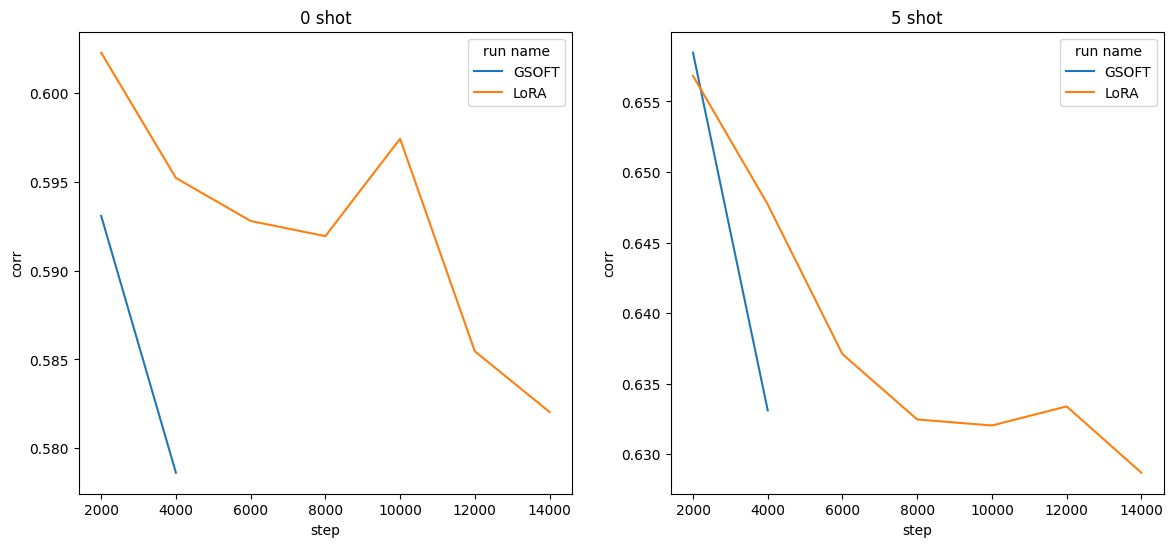

In [17]:
_, ax = plt.subplots(ncols=2, figsize=(14, 6))

sns.lineplot(
    data=total_acc[total_acc['num shots'] == 0],
    x='step',
    y='corr',
    hue='run name',
    ax=ax[0],
    markers='x'
)
ax[0].set_title('0 shot')

sns.lineplot(
    data=total_acc[total_acc['num shots'] == 5],
    x='step',
    y='corr',
    hue='run name',
    ax=ax[1],
    markers='x'
)
ax[1].set_title('5 shot')

In [18]:
sorted(all_preds['category'].unique())

['STEM', 'humanities', 'other (business, health, misc.)', 'social sciences']

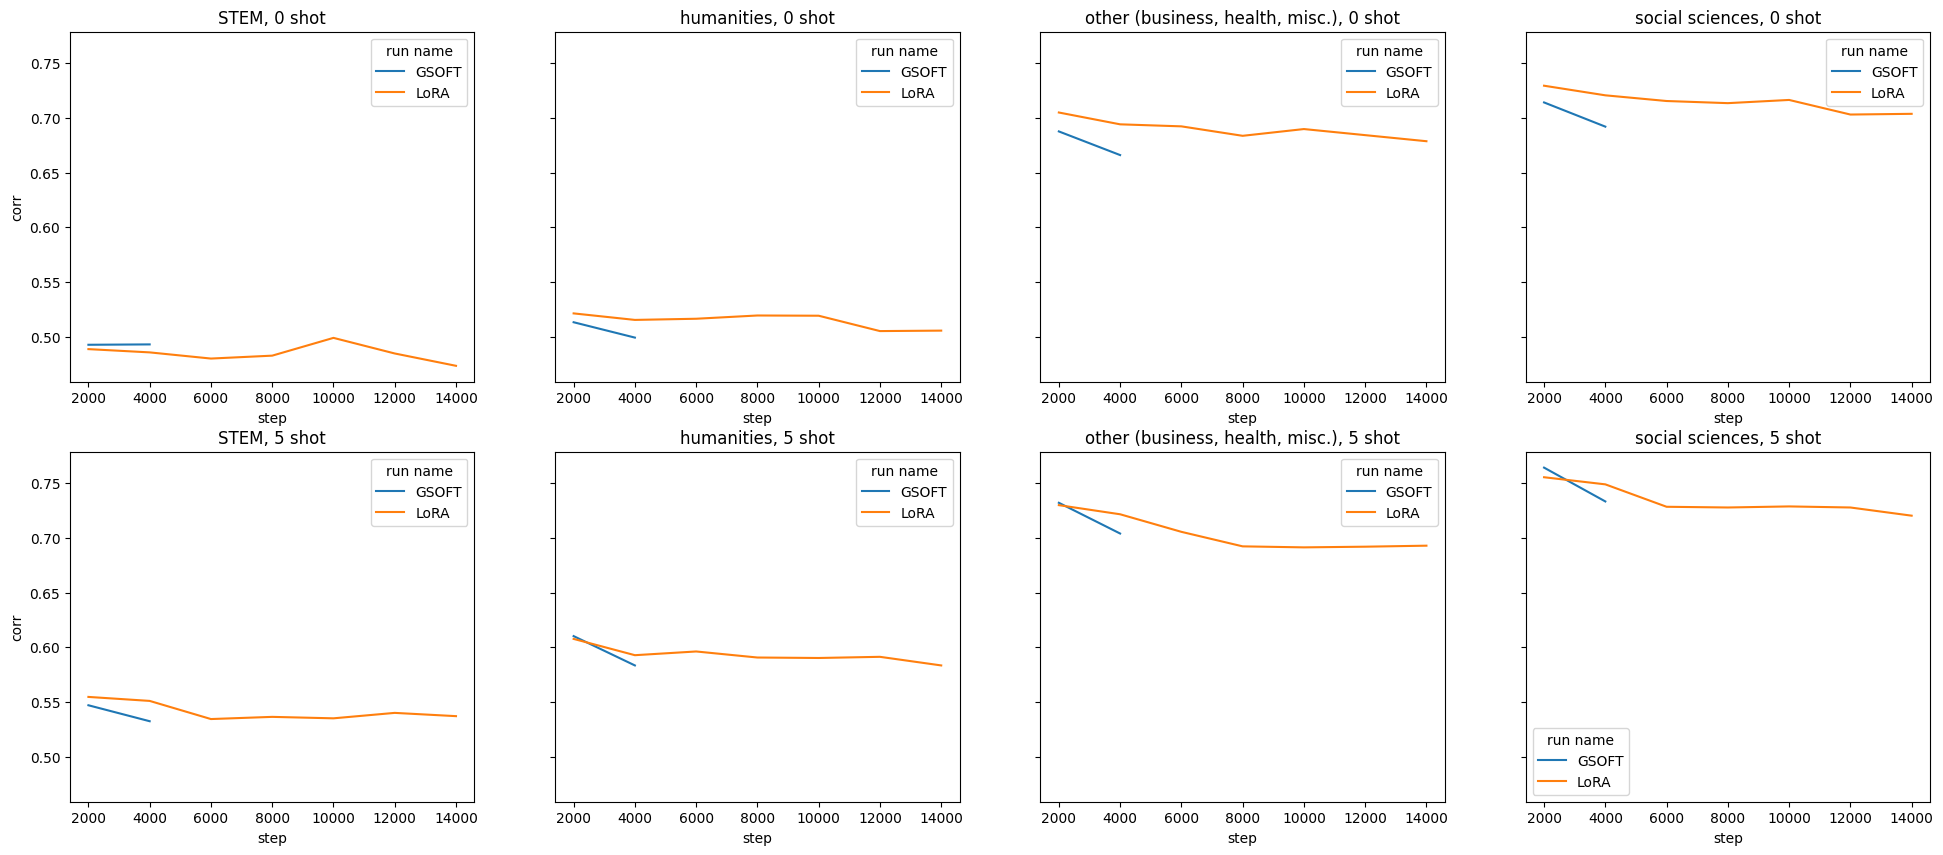

In [19]:
_, ax = plt.subplots(nrows=2, ncols=4, figsize=(24, 10), sharey=True)

for i, num_shots in enumerate([0, 5]):
    for j, category in enumerate(sorted(all_preds['category'].unique())):
        sns.lineplot(
            data=acc_by_categories[(acc_by_categories['num shots'] == num_shots) & (acc_by_categories['category'] == category)],
            x='step',
            y='corr',
            hue='run name',
            ax=ax[i, j],
            markers='x'
        )
        ax[i, j].set_title(f'{category}, {num_shots} shot')